# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Amar Bachtiar Tirta Cindhana
- **Email:** amartirtaa@gmail.com
- **ID Dicoding:** CDCC006C6Y1927

## Menentukan Pertanyaan Bisnis

- Metode pembayaran apa yang paling sering digunakan dan paling menghasilkan nilai transaksi terbesar sejak 2016 - 2018?
- Pada setiap tahun, kategori produk apa yang secara konsisten menghasilkan revenue tertinggi berdasarkan total pembayaran?

## Import Semua Packages/Library yang Digunakan

In [7]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
import seaborn as sns
import os

## Data Wrangling

### Gathering Data

In [8]:
customers = pd.read_csv('dataset/customers_dataset.csv')
geoloct = pd.read_csv('dataset/geolocation_dataset.csv')
order_items = pd.read_csv('dataset/order_items_dataset.csv')
order_payments = pd.read_csv('dataset/order_payments_dataset.csv')
order_review = pd.read_csv('dataset/order_reviews_dataset.csv')
orders = pd.read_csv('dataset/orders_dataset.csv')
products = pd.read_csv('dataset/products_dataset.csv')
sellers = pd.read_csv('dataset/sellers_dataset.csv')
product_translations = pd.read_csv('dataset/product_category_name_translation.csv')


In [9]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
geoloct.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [11]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [13]:
order_review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [14]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [17]:
product_translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Terdapat beberapa variabel kategorik seperti state, city, payment type, dan lain sebagainya
- Terdapat beberapa variabel numrtik seperti freight value, payment value, price, dan lain sebagainya

### Assessing Data

In [18]:
#ASSESING DATA CUSTOMERS
print(customers.isnull().sum(),'\n')
print(f'jumlah data duplikat: {customers.duplicated().sum()}','\n')
print(customers.info())


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64 

jumlah data duplikat: 0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None


In [19]:
#ASSESING DATA GEOLOCATION
print(geoloct.isnull().sum(),'\n')
print(geoloct.info())

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
None


In [20]:
#ASSESING DATA ORDER_ITEMS
print(order_items.isnull().sum(),'\n')
print(f'jumlah data duplikat: {order_items.duplicated().sum()}','\n')
print(order_items.info())

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64 

jumlah data duplikat: 0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None


In [21]:
#ASSESING DATA ORDER_PAYMENTS
print(order_payments.isnull().sum(),'\n')
print(f'jumlah data duplikat: {order_payments.duplicated().sum()}','\n')
print(order_payments.info())

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64 

jumlah data duplikat: 0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
None


In [22]:
#ASSESING DATA ORDER_REVIEWS
print(order_review.isnull().sum(),'\n')
print(f'jumlah data duplikat: {order_review.duplicated().sum()}','\n')
print(order_review.info())

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64 

jumlah data duplikat: 0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
None


In [23]:
#ASSESING DATA ORDERS
print(orders.isnull().sum(),'\n')
print(f'jumlah data duplikat: {orders.duplicated().sum()}', '\n')
print(orders.info())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64 

jumlah data duplikat: 0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estim

In [24]:
#ASSESING DATA PRODUCTS 
print(products.isnull().sum(),'\n')
print(f'jumlah data duplikat: {products.duplicated().sum()}')
print(products.info())

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64 

jumlah data duplikat: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           3

In [25]:
#ASSESING DATA SELLERS
print(sellers.isnull().sum(),'\n')
print(f'jumlah data duplikat: {sellers.duplicated().sum()}')

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64 

jumlah data duplikat: 0


**insights dari Assessing Data**
- pada dataset order_review, terdapat beberapa variabel yang memiliki missing value (review_comment_title dan review_comment_messege)
- pada dataset orders, juga terdapat beberapa variabel yang memiliki missing value (order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date)
- pada datset products, seluruh variabel memiliki missing value (kecuali product_id)



### Cleaning Data

In [26]:
#Mengubah review_comment_title yang kosong menjadi "No Title"
order_review['review_comment_title'] = order_review['review_comment_title'].fillna('No Title')

#Mengubah KOMENTAR REVIEW YANG kosong menjadi "No Comment"
order_review['review_comment_message'] = order_review['review_comment_message'].fillna('No Comment')

print(order_review.isnull().sum(),'\n')

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64 



In [27]:
#Mengubah data type yang berkaitan dengan tanggal menjadi datetime
date_columns_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for column in date_columns_orders:
    orders[column] = pd.to_datetime(orders[column], errors='coerce')

In [28]:
#Mengubah order_approved_at yang kosong menjadi order_purchase_timestamp
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])

#Mengubah order_delivered_carrier_date yang kosong menjadi order_estimated_delivery_date
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].fillna(orders['order_estimated_delivery_date'])

#Mengubah order_delivered_customer_date  yang kosong menjadi order_estimated_delivery_date
orders['order_delivered_customer_date'] = orders['order_delivered_customer_date'].fillna(orders['order_estimated_delivery_date'])

print(orders.isnull().sum())

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [29]:
#Mengubah product_category_name yang kosong menjadi "No Category"
products['product_category_name'] = products['product_category_name'].fillna('No Category')

#Mengisi product_name_lenght yang kosong dengan nilai rata-rata
products['product_name_lenght'] = products['product_name_lenght'].fillna(products['product_name_lenght'].mean())

#Mengisi product_description_lenght yang kosong dengan nilai rata-rata
products['product_description_lenght'] = products['product_description_lenght'].fillna(products['product_description_lenght'].mean())

#Mengisi product_photos_qty yang kosong dengan nilai rata-rata
products['product_photos_qty'] = products['product_photos_qty'].fillna(products['product_photos_qty'].mean())

#Mengisi product_weight_g yang kosong dengan nilai rata-rata
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].mean())

#Mengisi product_length_cm yang kosong dengan nilai rata-rata
products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].mean())

#Mengisi product_height_cm yang kosong dengan nilai rata-rata
products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].mean())

#Mengisi product_width_cm yang kosong dengan nilai rata-rata
products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].mean())

print(products.isnull().sum())

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- mengubah data kategorik yang kosong menjadi makna baru seperti "no_title", "no_comment", "no_category", dan lain sebagainya
- mengisi data numerik yang kosong menggunakan nilai rata-rata

## Exploratory Data Analysis (EDA)

### Eksplorasi data 

In [30]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99441,99441,99441,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 19:07:21.164720896,2018-01-03 23:29:23.449764096,2018-01-13 06:50:40.982220800,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-09-30 00:00:00,2016-09-30 00:00:00,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 21:55:13,2017-09-14 23:13:41,2017-09-22 21:28:06,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:54:30,2018-01-23 20:32:30,2018-02-01 19:34:49,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 23:50:21,2018-05-08 11:19:00,2018-05-15 17:51:03,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-10-17 17:30:18,2018-11-12 00:00:00,2018-11-12 00:00:00,2018-11-12 00:00:00


In [31]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [32]:
order_payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


In [33]:
#Merge df menjadi satu dataset untuk analisis lebih lanjut
df1 = orders.merge(order_items, on='order_id', how='left')
df2 = df1.merge(order_payments, on='order_id', how='left')
df3 = df2.merge(products, on='product_id', how='left')
df_all = df3.merge(product_translations, on='product_category_name', how='left')
df_all.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [34]:
#Group by untuk melihat jumlah pesanan per bulan untuk setiap tahun
# Groupby untuk melihat jumlah pesanan per bulan (Januari-Desember) untuk setiap tahun
df_all['year'] = df_all['order_purchase_timestamp'].dt.year
df_all['month'] = df_all['order_purchase_timestamp'].dt.month

# Groupby berdasarkan tahun dan bulan
monthly_order_by_year = df_all.groupby(['year', 'month']).size().reset_index(name='jumlah_pesanan')

# Urutkan berdasarkan tahun dan bulan
monthly_order_by_year = monthly_order_by_year.sort_values(['year', 'month'])

# Tampilkan hasil
print(monthly_order_by_year)

    year  month  jumlah_pesanan
0   2016      9               7
1   2016     10             397
2   2016     12               1
3   2017      1            1017
4   2017      2            2112
5   2017      3            3223
6   2017      4            2869
7   2017      5            4436
8   2017      6            3812
9   2017      7            4902
10  2017      8            5223
11  2017      9            5149
12  2017     10            5635
13  2017     11            9111
14  2017     12            6616
15  2018      1            8597
16  2018      2            7956
17  2018      3            8567
18  2018      4            8266
19  2018      5            8248
20  2018      6            7397
21  2018      7            7351
22  2018      8            7522
23  2018      9              16
24  2018     10               4


In [35]:
#Melihat produk yang paling banyak dipesan (dalam bentuk product id)
top_products = df_all.groupby('product_id').size().reset_index(name='total_orders')
top_products = top_products.sort_values(by='total_orders', ascending=False)
top_products.head(5)

,product_id,total_orders
22112,aca2eb7d00ea1a7b8ebd4e68314663af,536
19742,99a4788cb24856965c36a24e339b6058,525
8613,422879e10f46682990de24d770e7f83d,505
7364,389d119b48cf3043d311335e499d9c6b,406
7079,368c6c730842d78016ad823897a372db,395


In [36]:
#Melihat kategori produk yang paling banyak dipesan
top_categories = df_all.groupby('product_category_name').size().reset_index(name='total_orders')
top_categories = top_categories.sort_values(by='total_orders', ascending=False)
top_categories.head(5)

,product_category_name,total_orders
14,cama_mesa_banho,11823
12,beleza_saude,9975
33,esporte_lazer,8945
55,moveis_decoracao,8744
45,informatica_acessorios,8082


In [37]:
#Kategori Produk Terlaris (translated)
top_categories = df_all.groupby('product_category_name_english').size().reset_index(name='total_orders')
top_categories = top_categories.sort_values(by='total_orders', ascending=False)
top_categories.head(5)

,product_category_name_english,total_orders
7,bed_bath_table,11823
43,health_beauty,9975
65,sports_leisure,8945
39,furniture_decor,8744
15,computers_accessories,8082


In [38]:
#Hitung revenue tiap kategori produk per tahun
revenue_yearly = df_all.groupby(['year', 'product_category_name_english'])['price'].sum().reset_index()
print(revenue_yearly)


     year product_category_name_english      price
0    2016              air_conditioning    1707.09
1    2016                         audio     156.99
2    2016                          auto    1833.25
3    2016                          baby    1630.16
4    2016                bed_bath_table     478.99
..    ...                           ...        ...
167  2018                    stationery  142528.67
168  2018        tablets_printing_image    1267.96
169  2018                     telephony  187765.45
170  2018                          toys  178351.61
171  2018                 watches_gifts  738306.32

[172 rows x 3 columns]


In [39]:
top_per_year = revenue_yearly.loc[
    revenue_yearly.groupby('year')['price'].idxmax()
]
top_per_year

,year,product_category_name_english,price
18,2016,furniture_decor,6468.07
38,2017,bed_bath_table,530875.53
145,2018,health_beauty,788700.91


In [40]:
top3_per_year = revenue_yearly.groupby('year').apply(lambda x: x.nlargest(3, 'price')).reset_index(drop=True)
top3_per_year

C:\Users\AMAR\AppData\Local\Temp\ipykernel_13496\2519398102.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_per_year = revenue_yearly.groupby('year').apply(lambda x: x.nlargest(3, 'price')).reset_index(drop=True)


,year,product_category_name_english,price
0,2016,furniture_decor,6468.07
1,2016,perfumery,5782.40
2,2016,health_beauty,4807.28
3,2017,bed_bath_table,530875.53
4,2017,watches_gifts,511476.74
5,2017,health_beauty,503982.58
6,2018,health_beauty,788700.91
7,2018,watches_gifts,738306.32
8,2018,bed_bath_table,561196.50


In [41]:
#Melihat distribusi metode pembayaran yang digunakan oleh pelanggan
payment_method_counts = df_all['payment_type'].value_counts()
print(payment_method_counts)


payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64


In [42]:
#Melihat Total Revenue per Payment Type
revenue_per_payment_type = df_all.groupby('payment_type')['payment_value'].sum().reset_index(name='total_revenue')
revenue_per_payment_type.sort_values(by='total_revenue', ascending=False)


,payment_type,total_revenue
1,credit_card,15694885.84
0,boleto,4086820.71
4,voucher,432602.19
2,debit_card,256417.92
3,not_defined,0.00


## Visualization & Explanatory Analysis

### Pertanyaan 1:

- Metode pembayaran apa yang paling sering digunakan dan paling menghasilkan nilai transaksi terbesar sejak 2016-2018?

In [43]:
#menghapus not_defined dari payment_method_counts
payment_method_counts = payment_method_counts[payment_method_counts.index != 'not_defined']

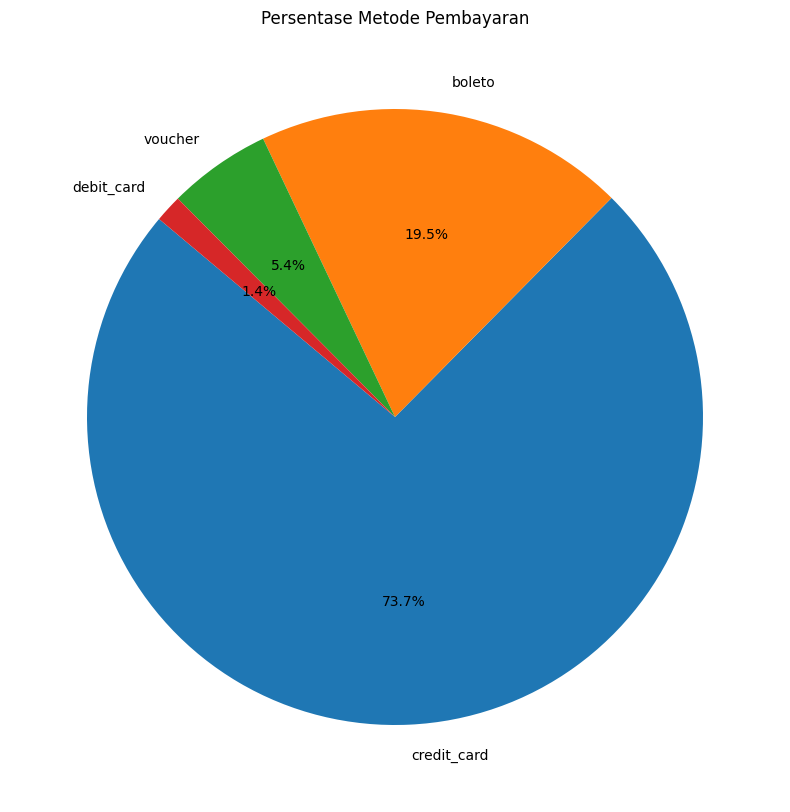

In [44]:
#Visualisasi pie chart payment type
plt.figure(figsize=(12, 10))
plt.pie(payment_method_counts, labels=payment_method_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Persentase Metode Pembayaran')
plt.show()

In [45]:
#Menghapus not_defined dari revenue_per_payment_type
revenue_per_payment_type = revenue_per_payment_type[revenue_per_payment_type['payment_type'] != 'not_defined']

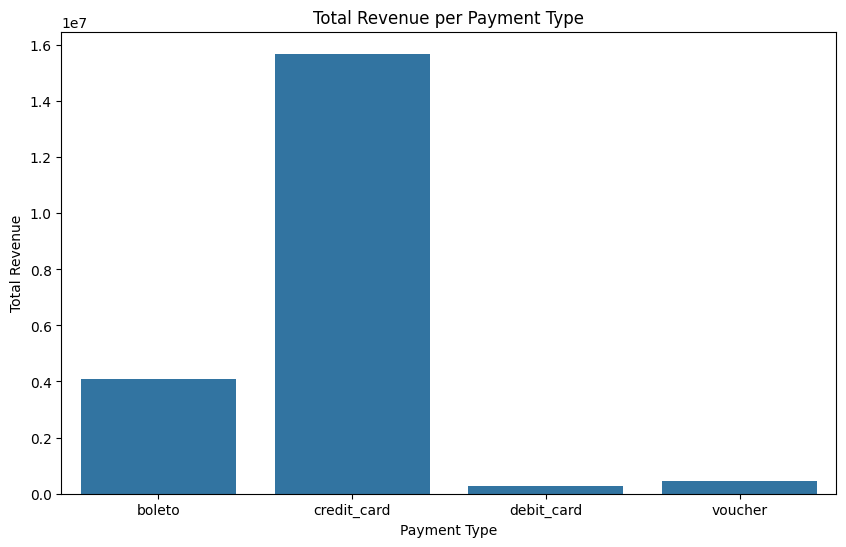

In [46]:
#Visualisasi revenue_per_payment_type 
plt.figure(figsize=(10, 6))
sns.barplot(x='payment_type', y='total_revenue', data=revenue_per_payment_type)
plt.title('Total Revenue per Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Revenue')
plt.show()

### Pertanyaan 2:


- Pada setiap tahun, kategori produk apa yang secara konsisten menghasilkan revenue tertinggi berdasarkan total pembayaran?

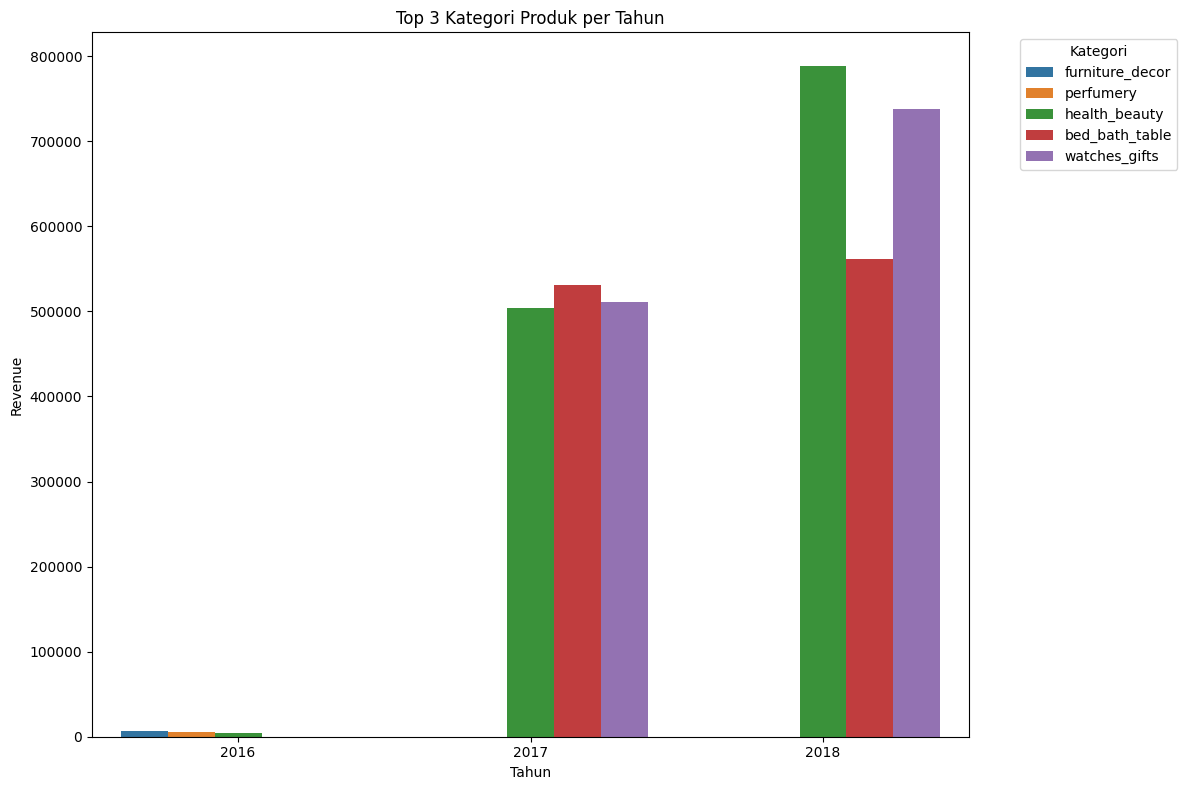

In [47]:
#Membuat stacked bar chart untuk 3 kategori produk terlaris per tahun
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top3_per_year,
    x='year',
    y='price',
    hue='product_category_name_english'
)

plt.title('Top 3 Kategori Produk per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Revenue')
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

**Insight:**
- xxx
- xxx

## Analisis Lanjutan (Opsional)

In [48]:
#RFM Analysis
# Pastikan datetime
df_all['order_purchase_timestamp'] = pd.to_datetime(df_all['order_purchase_timestamp'])

In [49]:
snapshot_date = df_all['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [50]:
rfm = df_all.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
    'customer_id': 'count',  # Frequency
    'payment_value': 'sum'   # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

# Recency: makin kecil makin bagus → dibalik
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

# Frequency & Monetary: makin besar makin bagus
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

def segment(row):
    if row['RFM_score'] == '444':
        return 'Best Customer'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customer'
    elif row['R_score'] == 4:
        return 'Recent Customer'
    elif row['F_score'] == 4:
        return 'Frequent Customer'
    elif row['M_score'] == 4:
        return 'Big Spender'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm.groupby('Segment').agg({
    'customer_id': 'count',
    'Monetary': 'mean'
}).sort_values(by='customer_id', ascending=False)

,customer_id,Monetary
Segment,,
Others,40235,89.743665
Loyal Customer,21976,202.692334
Recent Customer,12709,155.153615
Frequent Customer,12540,364.567959
Big Spender,9196,414.684506
Best Customer,2785,735.567447


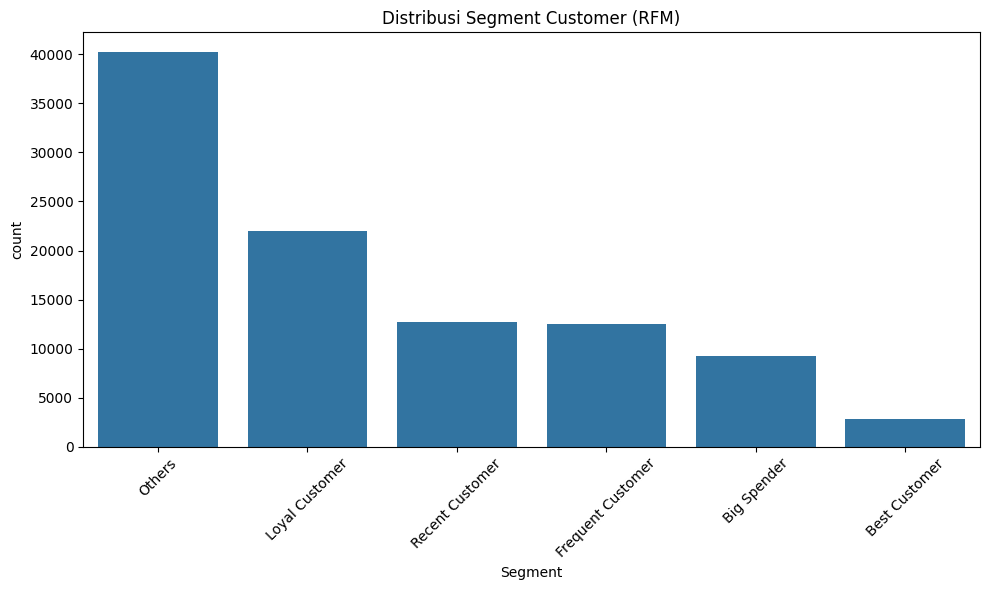

In [51]:
plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Distribusi Segment Customer (RFM)')
plt.tight_layout()

In [52]:
rfm_summary = rfm.groupby('Segment').agg({
    'customer_id': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(2)

rfm_summary.sort_values(
    ('Monetary', 'sum'), ascending=False
)
rfm[rfm['Segment'] == 'Best Customer']
rfm[rfm['Segment'] == 'At Risk']
rfm_summary[('customer_id', 'percentage')] = (
    rfm_summary[('customer_id', 'count')] /
    rfm_summary[('customer_id', 'count')].sum() * 100
).round(2)
rfm_summary.columns = [
    'Total Customer',
    'Avg Recency',
    'Avg Frequency',
    'Avg Monetary',
    'Total Revenue',
    'Percentage (%)'
]

rfm_summary = rfm_summary.sort_values(
    by='Total Revenue', ascending=False
)

rfm_summary

,Total Customer,Avg Recency,Avg Frequency,Avg Monetary,Total Revenue,Percentage (%)
Segment,,,,,,
Frequent Customer,12540,419.58,1.78,364.57,4571682.21,12.61
Loyal Customer,21976,170.86,1.26,202.69,4454366.73,22.10
Big Spender,9196,371.09,1.00,414.68,3813438.72,9.25
Others,40235,367.91,1.00,89.74,3610836.37,40.46
Best Customer,2785,111.63,2.26,735.57,2048555.34,2.80
Recent Customer,12709,108.97,1.00,155.15,1971847.29,12.78


Insight
- Retensi lemah: Banyak customer high value tidak kembali
- Loyalty belum terbentuk: Frequency hampir semua segmen rendah (average/mean di angka sekitar 1)
- Revenue tidak sustainable: Bergantung pada transaksi satu kali (one-time purchase)

## Conclusion

- Conclusion pertanyaan "Metode pembayaran apa yang paling sering digunakan dan paling menghasilkan nilai transaksi terbesar sejak 2016-2018?"
    1. Berdasarkan hasil visualisasi pie chat, diperoleh bahwa 73.7% pengguna melakukan pembelian barang dengan metode pembayaran via credit_card, dilanjut dengan metode pembayaran boleto yang hanya 19.5%. Dengan demikian, metode pembayaran via credit_card mendominasi dan menjadi metode pembayaran yang paling sering digunakan oleh pengguna.
    2. Berdasarkan hasil visualisasi bar chart, diperoleh bahwa metode pembayaran credit_card menghasilkan nilai transaksi terbesar, hal ini sejalan dengan metode pembayaran yang paling sering digunakan oleh pengguna yakni adalah credit_card.


- Conclusion pertanyaan "Pada setiap tahun, kategori produk apa yang secara konsisten menghasilkan revenue tertinggi berdasarkan total pembayaran?"
    1. Dari hasil visualisasi terlihat bahwa untuk setiap tahun (2016-2018), 3 kategori produk yang sering dibeli di tahun 2016 adalah furniture_decor, perfumery, dan health_beauty. Lalu pada tahun 2017 dan 2018, top 3 kategori yang sering dibeli adalah health_beauty, bed_bath_table, dan watches gifts.
    2. Berdasarkan stacked bar chart mengenai top 3 produk yang menghasilkan revenue paling tinggi untuk tiap tahun, jumlah revenue untuk 3 top kategori di tahun 2016 masih sangat kecil, menunjukkan intensitas dan daya beli online/via e-commerce pengguna masih rendah pada tahun 2016, sedangkan pada tahun 2017 dan 2018 terjadi lonjakan tinggi pendapatan (revenue) yang diperoleh
    3. Berdasarkan hasil visualisasi, kategori produk yang konsisten menempati top 3 penyumbang revenue tertinggi adalah kategori health_beauty

- Rekomendasi bisnis:
    1. Maksimalkan channel credit card dengan menjalin kerjasama dengan bank untuk mengadakan promo dan cashback untuk tiap pembelanjaan menggunakan credit card. Dengan demikian kita dapat meningkatkan conversion rate & average transaction value
    2. Karena kategori produk health_beauty yang konsisten berada di top 3 penyumbang revenue tertinggi untuk setiap tahun, kita dapat mengadakan cross selling/bundling dengan produk lain, misal produk health_beauty + perfumery. Hal ini dapat dilakukan untuk meningkatkan sales produk lain.

In [53]:
df_all.to_csv('BFAD_file.csv', index=False)